# Curve Fitting Comparison — SLP MNIST

## Overview
This notebook fits `CE(x) = A + B / (x+1)^n` to each individual training run, then compares two averaging strategies:

| Method | Approach | Line style |
|--------|----------|------------|
| **Per-run fit average** | Fit each run independently → average the fitted curves | Solid, full opacity |
| **v_4 single fit** | Average all raw runs first → fit one curve to the average | Dashed, dim (α = 0.3) |

## Workflow

| Cell | Purpose |
|------|---------|
| **1** | Config, imports, fitting function, auto-detect pruning % |
| **2** | Per-run fitting → save `per_run_fits_p_{p}_bs_{bs}.csv` and `mean_fit_p_{p}_bs_{bs}.csv` |
| **3** | Load v_4 averaged data → single fit → save `v4_single_fit_p_{p}_bs_{bs}.csv` |
| **4** | Comparison plot: per-run mean fit (bright) vs v_4 single fit (dim) |

## Cell 1 — Configuration, Imports & Fitting Function

Sets up everything needed by all subsequent cells:

- **Imports**: `numpy`, `pandas`, `matplotlib`, `scipy.optimize.curve_fit`
- **Paths**: `BASE_DIR` (raw data), `OUT_DIR` (fitted curve CSVs)
- **Auto-detect pruning %**: Scans `p-percentage_*` directories — finds all percentages including fine-grained ones (82%, 84%, 86%, 88%, 92%, 94%, 96%, 98%)
- **Color palette**: 20-color reversed list — consistent with v_4 and Conv-MNIST notebooks
- **Style**: `plt.rcParams` set to match Conv-MNIST (`font.size=18`, tick sizes 16, legend 14)
- **`power_decay(x, A, B, n)`**: The fitting model `CE(x) = A + B / (x+1)^n`
- **`fit_run(batch_numbers, ce_values)`**: Fits one run's CE_TEST series; returns `(A, B, n)` or `None` on failure

In [19]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Parameters, minimize
import warnings
warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR  = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL"
OUT_DIR   = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_IPA_curves_data"

BATCH_SIZES = [64, 1024, 60000]
LN10        = np.log(10)

# ── Auto-detect pruning percentages from directory names ─────────────────────
p_dirs = glob.glob(os.path.join(BASE_DIR, "p-percentage_*"))
PRUNING_LEVELS = sorted([
    float(re.search(r"p-percentage_([\d.]+)", d).group(1))
    for d in p_dirs
])
print(f"Found {len(PRUNING_LEVELS)} pruning percentages: {PRUNING_LEVELS}")

# ── Color palette ─────────────────────────────────────────────────────────────
# COLOR_LIST_BASE = [
#     "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#800080",
#     "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#B9D9EB", "#17becf",
#     "#C5B0D5", "#FDB462", "#80B1D3", "#FB8072", "#BEBADA",
#     "#8DD3C7", "#FFFFB3", "#A6D854", "#FCCDE5"
# ]


COLOR_LIST_BASE = [
    "#17becf",  # 0%
    "#B9D9EB",  # 10%
    "#bcbd22",  # 20%
    "#7f7f7f",  # 30%
    "#e377c2",  # 40%
    "#8c564b",  # 50%
    "#800080",  # 60%
    "#d62728",  # 70%
    "#2ca02c",  # 80%
    "#FCCDE5",  # new
    "#FB8072",  # new
    "#A6D854",  # new
    "#FFFFB3",  # new
    "#8DD3C7",  # 90%
    "#BEBADA",  # new
    "#80B1D3",  # new
    "#FDB462",  # new
    "#C5B0D5",  # new
    "#1f77b4"   # 100%
]
n_colors   = len(PRUNING_LEVELS)
COLOR_LIST = (COLOR_LIST_BASE * ((n_colors // len(COLOR_LIST_BASE)) + 1))[:n_colors]
# COLOR_LIST = COLOR_LIST[::-1]
P_COLOR    = {p: COLOR_LIST[i] for i, p in enumerate(PRUNING_LEVELS)}


# ── FIT PARAMETERS ────────────────────────────────────────────────────────────
A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0, 1000
N_MIN, N_MAX = 0.5, 3.0


# ── FITTING FUNCTIONS (lmfit approach) ────────────────────────────────────────
def initialize_guesses(x, y):
    """Smart initial parameter estimation for CE power-law fit."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5

    if len(x) > 10:
        denom = y[0] - A0
        if abs(denom) > 1e-10:
            frac = max(1e-6, (y[0] - y[-1]) / denom)
            if frac > 0:
                n0 = max(0.3, min(1.5, -np.log(frac)))

    return A0, n0, B0


def model(params, x):
    """Model function: A + B / (x+1)^n"""
    vals = params.valuesdict()
    A, B, n = vals['A'], vals['B'], vals['n']
    return A + B / ((x + 1)**n)


def residual(params, x, data):
    """Weighted residual: weight = x"""
    weight = x
    return weight * (model(params, x) - data)


def fit_curve(x, y):
    """Fit CE curve using lmfit. Returns lmfit result or None."""
    mask  = ~np.isnan(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 10:
        return None

    A0, n0, B0 = initialize_guesses(x_fit, y_fit)

    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)

    try:
        return minimize(residual, params, args=(x_fit, y_fit))
    except Exception:
        return None



print("Cell 1 ready.")


Found 19 pruning percentages: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.82, 0.84, 0.86, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0]
Cell 1 ready.


## Cell 2 — Per-Run Fitting & Mean Curve

For each `(pruning %, batch size)` combination:

1. **Loads** all individual run files: `slp_{P%}_{BS}_run_*.txt`
2. **Fits** `power_decay` to the `CE_TEST` column of each run independently → extracts `(A, B, n)` per run
3. **Evaluates** each fitted curve on the union of all batch numbers in that group
4. **Averages** the fitted curves point-by-point across all valid runs
5. **Saves** two CSVs to `Fitting_IPA_curves_data/BS_{BS}/`:
   - `per_run_fits_p_{P%}_bs_{BS}.csv` — individual fitted curves (columns: `Run, Batch_Number, Fitted_CE, A, B, n`)
   - `mean_fit_p_{P%}_bs_{BS}.csv` — averaged curve (columns: `Batch_Number, Mean_Fit_CE, Std_Fit_CE`)

Results are stored in `PER_RUN_MEAN[(p, bs)]` for use in Cell 4.

In [20]:
# =============================================================================
# CELL 2 — Per-run fitting
#   For each (P%, BS):
#     1. Load every raw run file
#     2. Fit CE curve to each run individually
#     3. Evaluate the fit on a common x-grid
#     4. Average the fitted curves point-by-point
#     5. Save:
#          per_run_fits_p_{p}_bs_{bs}.csv   — one fitted-curve row per run
#          mean_fit_p_{p}_bs_{bs}.csv       — averaged fitted curve
# =============================================================================

PER_RUN_MEAN  = {}   # (p, bs) → DataFrame(Batch_Number, Mean_Fit_CE, Std_Fit_CE)
MEAN_CE_ASYM  = {}   # (p, bs) → mean A (CE asymptote) across valid runs
PER_RUN_PARAMS = {}  # (p, bs) → DataFrame with A, B, n summary

for bs in BATCH_SIZES:
    bs_dir = os.path.join(OUT_DIR, f"BS_{bs}")
    os.makedirs(bs_dir, exist_ok=True)

    print(f"\n{'='*55}")
    print(f"  Batch size {bs}")
    print(f"{'='*55}")

    for p in PRUNING_LEVELS:
        folder = os.path.join(BASE_DIR, f"p-percentage_{p}", f"batch_size_{bs}")
        files  = sorted(glob.glob(os.path.join(folder, f"slp_{p}_{bs}_run_*.txt")))

        if not files:
            print(f"  [SKIP] P%={p*100:.1f}%  — no files found")
            continue

        run_params = []
        run_curves = []
        run_rows   = []

        for fpath in files:
            try:
                df = pd.read_csv(fpath, sep=r"\s+")
                df.columns = df.columns.str.strip()
                df["CE_TEST"]      = pd.to_numeric(df["CE_TEST"],      errors="coerce")
                df["Batch_Number"] = pd.to_numeric(df["Batch_Number"], errors="coerce")
                df = df.dropna(subset=["CE_TEST", "Batch_Number"])
                if len(df) < 5:
                    continue
            except Exception:
                continue

            x = df["Batch_Number"].values
            y = df["CE_TEST"].values
            result = fit_curve(x, y)
            if result is None:
                continue

            vals = result.params.valuesdict()
            A, B, n = vals['A'], vals['B'], vals['n']
            fitted_y = A + B / ((x + 1)**n)
            run_params.append((A, B, n))
            run_curves.append((x, fitted_y))

            run_name = os.path.basename(fpath)
            for xi, yi in zip(x, fitted_y):
                run_rows.append({"Run": run_name, "Batch_Number": xi,
                                 "Fitted_CE": yi, "A": A, "B": B, "n": n})

        n_valid = len(run_params)
        print(f"  P%={p*100:5.1f}%  files={len(files)}  fitted={n_valid}")

        if n_valid == 0:
            continue

        # Save per-run fits
        per_run_csv = os.path.join(bs_dir, f"per_run_fits_p_{p}_bs_{bs}.csv")
        pd.DataFrame(run_rows).to_csv(per_run_csv, index=False)

        # Average fitted curves on a shared x-grid
        all_x = np.sort(np.unique(np.concatenate([c[0] for c in run_curves])))
        fitted_matrix = np.array([A + B / ((all_x + 1)**n) for A, B, n in run_params])

        mean_fit = fitted_matrix.mean(axis=0)
        std_fit  = fitted_matrix.std(axis=0)
        mean_A   = np.mean([p_[0] for p_ in run_params])   # mean CE asymptote
        mean_B   = np.mean([p_[1] for p_ in run_params])   # mean B
        mean_n   = np.mean([p_[2] for p_ in run_params])   # mean n
        std_A    = np.std([p_[0] for p_ in run_params])
        std_B    = np.std([p_[1] for p_ in run_params])
        std_n    = np.std([p_[2] for p_ in run_params])

        mean_df = pd.DataFrame({
            "Batch_Number": all_x,
            "Mean_Fit_CE":  mean_fit,
            "Std_Fit_CE":   std_fit,
        })
        mean_csv = os.path.join(bs_dir, f"mean_fit_p_{p}_bs_{bs}.csv")
        mean_df.to_csv(mean_csv, index=False)

        PER_RUN_MEAN[(p, bs)] = mean_df
        MEAN_CE_ASYM[(p, bs)] = mean_A
        PER_RUN_PARAMS[(p, bs)] = {
            "A_mean": mean_A, "A_std": std_A,
            "B_mean": mean_B, "B_std": std_B,
            "n_mean": mean_n, "n_std": std_n,
            "n_runs": n_valid
        }

print("\n✓ Cell 2 complete.")


  Batch size 64
  P%=  0.0%  files=100  fitted=100
  P%= 10.0%  files=100  fitted=100
  P%= 20.0%  files=100  fitted=100
  P%= 30.0%  files=100  fitted=100
  P%= 40.0%  files=100  fitted=100
  P%= 50.0%  files=100  fitted=100
  P%= 60.0%  files=100  fitted=100
  P%= 70.0%  files=100  fitted=100
  P%= 80.0%  files=100  fitted=100
  P%= 82.0%  files=63  fitted=63
  P%= 84.0%  files=63  fitted=63
  P%= 86.0%  files=63  fitted=63
  P%= 88.0%  files=63  fitted=63
  P%= 90.0%  files=100  fitted=100
  P%= 92.0%  files=63  fitted=63
  P%= 94.0%  files=62  fitted=62
  P%= 96.0%  files=62  fitted=62
  P%= 98.0%  files=62  fitted=62
  P%=100.0%  files=100  fitted=100

  Batch size 1024
  P%=  0.0%  files=100  fitted=100
  P%= 10.0%  files=100  fitted=100
  P%= 20.0%  files=100  fitted=100
  P%= 30.0%  files=100  fitted=100
  P%= 40.0%  files=100  fitted=100
  P%= 50.0%  files=100  fitted=100
  P%= 60.0%  files=100  fitted=100
  P%= 70.0%  files=100  fitted=100
  P%= 80.0%  files=100  fitted=100


## Cell 3 — v_4 Single Fit on Averaged Data

This cell implements the **v_4 approach** for comparison:

- **v_4 method**: Average all raw runs first → fit *one* curve to the averaged CE_Test
- Loads `averaged_runs_p_{P%}_bs_{BS}.csv` written by the v_4 notebook (run that first if file is missing)
- Fits `power_decay` to the `Avg_CE_Test` column
- Saves `v4_single_fit_p_{P%}_bs_{BS}.csv` to `Fitting_IPA_curves_data/BS_{BS}/`

Results are stored in `V4_FIT[(p, bs)]` for use in Cell 4.

> **Note**: Run `v_4_Combined_experiment_avg_and_plot.ipynb` Cell 1 first if averaged files are missing.

In [21]:
# =============================================================================
# CELL 3 — v_4 single-fit on the averaged data
# =============================================================================

V4_FIT      = {}   # (p, bs) → DataFrame(Batch_Number, Fit_CE)
V4_CE_ASYM  = {}   # (p, bs) → A from single fit on averaged curve
V4_PARAMS   = {}   # (p, bs) → (A, B, n) from single fit

for bs in BATCH_SIZES:
    bs_dir = os.path.join(OUT_DIR, f"BS_{bs}")
    os.makedirs(bs_dir, exist_ok=True)

    print(f"\n{'='*55}")
    print(f"  v_4 single fit — Batch size {bs}")
    print(f"{'='*55}")

    for p in PRUNING_LEVELS:
        folder  = os.path.join(BASE_DIR, f"p-percentage_{p}", f"batch_size_{bs}")
        avg_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

        if not os.path.exists(avg_csv):
            print(f"  [SKIP] P%={p*100:.1f}%  — averaged file not found (run v_4 first)")
            continue

        try:
            avg_df = pd.read_csv(avg_csv)
            avg_df.columns = avg_df.columns.str.strip()
        except Exception as e:
            print(f"  [ERROR] P%={p*100:.1f}%  — {e}")
            continue

        ce_col = next((c for c in avg_df.columns if "CE_Test" in c or "CE_TEST" in c), None)
        bn_col = next((c for c in avg_df.columns if "Batch" in c), None)
        if ce_col is None or bn_col is None:
            print(f"  [ERROR] P%={p*100:.1f}%  — unexpected columns: {list(avg_df.columns)}")
            continue

        x = avg_df[bn_col].values.astype(float)
        y = avg_df[ce_col].values.astype(float)

        result = fit_curve(x, y)
        if result is None:
            print(f"  [FAIL]  P%={p*100:.1f}%  — fit did not converge")
            continue

        vals = result.params.valuesdict()
        A, B, n = vals['A'], vals['B'], vals['n']
        fit_y = A + B / ((x + 1)**n)

        fit_df = pd.DataFrame({"Batch_Number": x, "Fit_CE": fit_y,
                               "A": A, "B": B, "n": n})
        out_csv = os.path.join(bs_dir, f"v4_single_fit_p_{p}_bs_{bs}.csv")
        fit_df.to_csv(out_csv, index=False)

        V4_FIT[(p, bs)]     = fit_df
        V4_CE_ASYM[(p, bs)] = A   # A from fit on averaged curve = A(<CE>)
        V4_PARAMS[(p, bs)]  = (A, B, n)
        print(f"  P%={p*100:5.1f}%  A={A:.4f}  B={B:.4f}  n={n:.4f}")

print("\n✓ Cell 3 complete.")


  v_4 single fit — Batch size 64
  P%=  0.0%  A=0.2993  B=5.8068  n=0.9046
  P%= 10.0%  A=0.2927  B=5.7789  n=0.8771
  P%= 20.0%  A=0.2986  B=7.2259  n=0.9292
  P%= 30.0%  A=0.2993  B=7.6436  n=0.9203
  P%= 40.0%  A=0.2986  B=8.4591  n=0.9154
  P%= 50.0%  A=0.2828  B=7.1199  n=0.8119
  P%= 60.0%  A=0.2847  B=7.5459  n=0.7812
  P%= 70.0%  A=0.3018  B=8.6419  n=0.7678
  P%= 80.0%  A=0.3154  B=8.2479  n=0.6761
  P%= 82.0%  A=0.3653  B=10.1706  n=0.7322
  P%= 84.0%  A=0.3550  B=9.0167  n=0.6703
  P%= 86.0%  A=0.5373  B=0.9990  n=0.5000
  P%= 88.0%  A=0.4376  B=9.9780  n=0.6712
  P%= 90.0%  A=0.4543  B=8.8413  n=0.6096
  P%= 92.0%  A=0.4552  B=6.8571  n=0.5075
  P%= 94.0%  A=0.5428  B=7.5046  n=0.5000
  P%= 96.0%  A=0.7119  B=8.2064  n=0.5000
  P%= 98.0%  A=1.5180  B=0.6803  n=0.5000
  P%=100.0%  A=2.3000  B=0.0000  n=0.5000

  v_4 single fit — Batch size 1024
  P%=  0.0%  A=0.2738  B=6.0539  n=1.0175
  P%= 10.0%  A=0.2738  B=7.7385  n=1.0722
  P%= 20.0%  A=0.2630  B=6.4888  n=0.9769
  P%=

## Cell 4 — Comparison Plot

Produces one figure per batch size comparing the two fitting strategies side by side:

| Line style | Method | Source |
|------------|--------|--------|
| **Solid, full opacity** | Mean of per-run fits (Cell 2) | `mean_fit_p_{P%}_bs_{BS}.csv` |
| **Dashed, α = 0.30** | v_4 single fit on averaged data (Cell 3) | `v4_single_fit_p_{P%}_bs_{BS}.csv` |

**Label format**: `P%=XX.X  CEasy=Y.YYY` — shows the mean fitted CE asymptote (parameter A) alongside pruning %.

**Legend**: Placed **outside the plot** (right side) using `bbox_to_anchor=(1.01, 1.0)` + `bbox_inches="tight"` on save. Two gray dummy entries at the bottom explain line styles.

**Output**: `Fitting_comparison_plots/CE_Test_Fit_Comparison_BS_{BS}.png` (300 DPI)

**Style**: Consistent with Conv-MNIST — `font.size=18`, `figsize=(14,6)` (wider for outside legend), `ylim=(0, 2.7)`, `ln(10)` text marker, `grid(True)`, reversed legend order.

Saved: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_comparison_plots\CE_Test_Fit_Comparison_BS_64.png


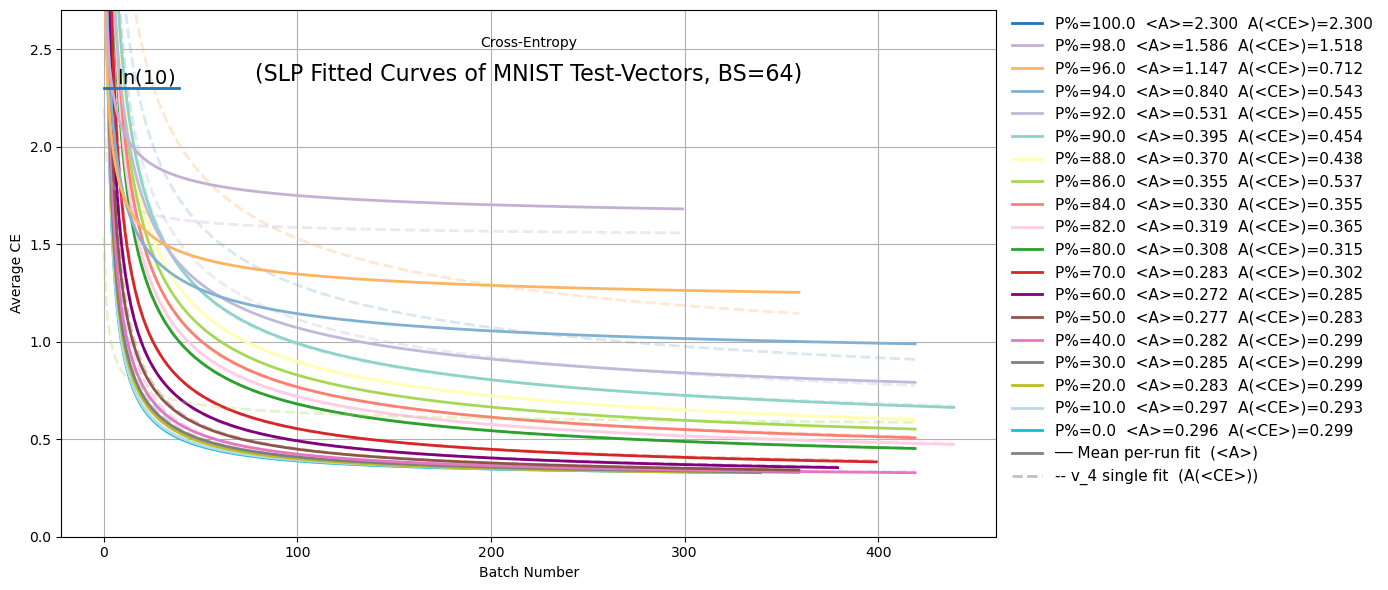

Saved: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_comparison_plots\CE_Test_Fit_Comparison_BS_1024.png


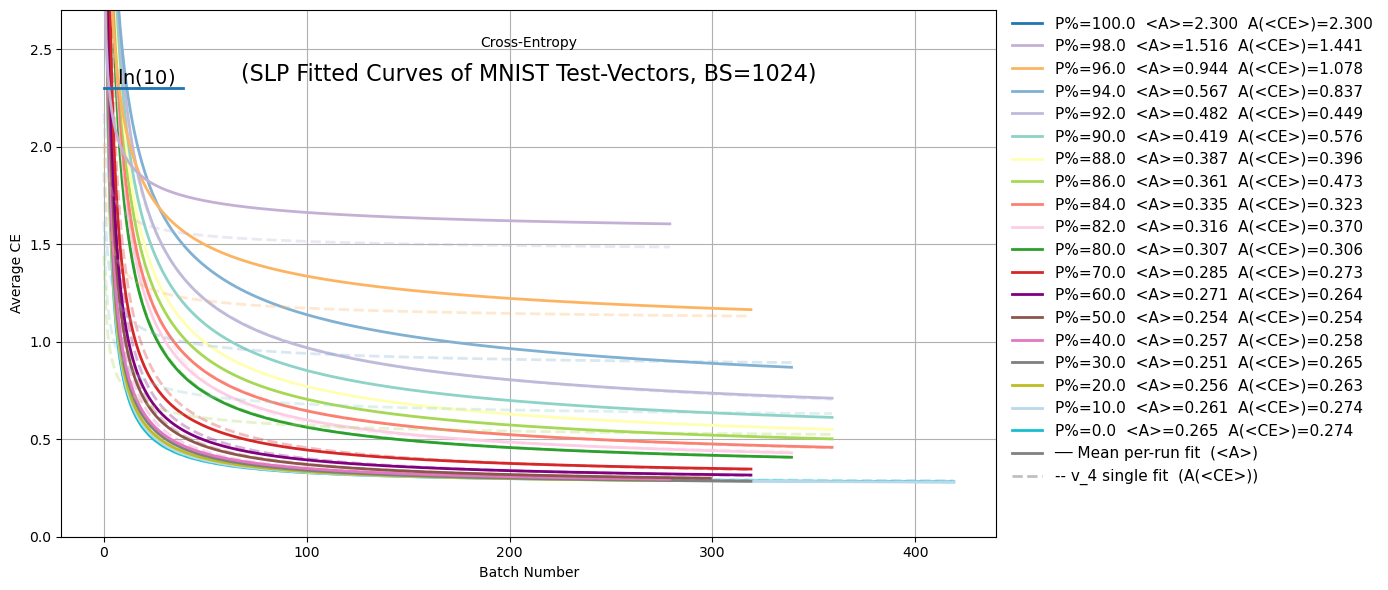

Saved: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_comparison_plots\CE_Test_Fit_Comparison_BS_60000.png


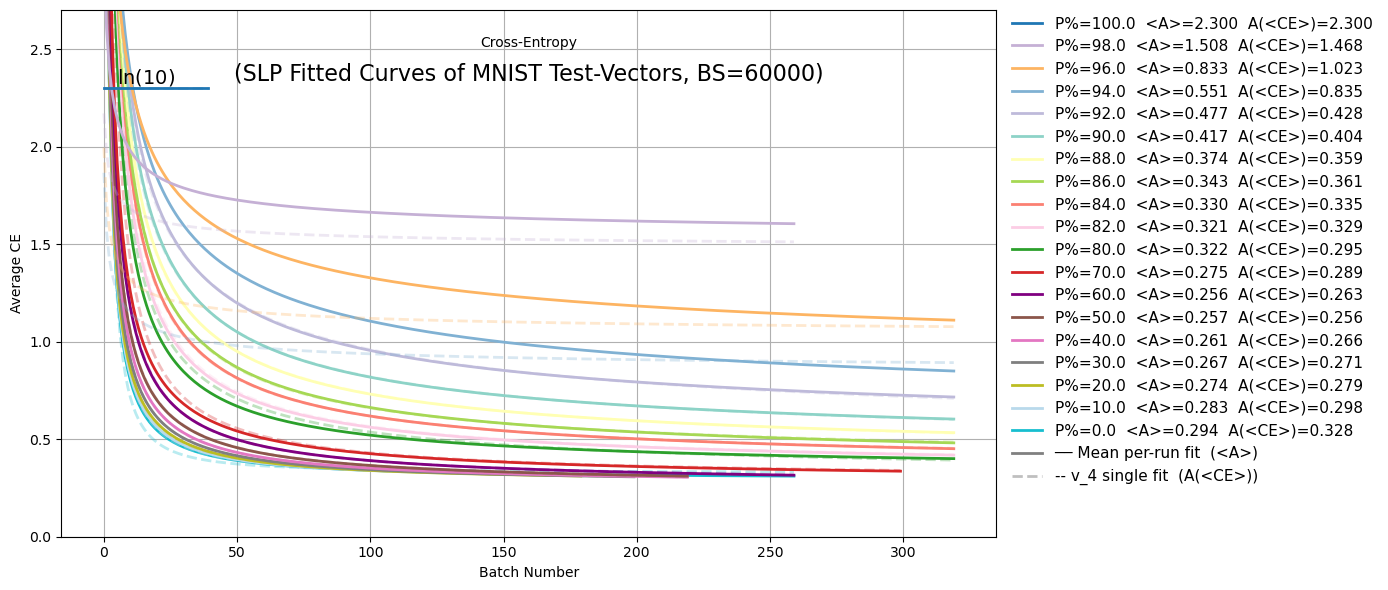


✓ Cell 4 complete.


In [22]:
# =============================================================================
# CELL 4 — Comparison plot  (Conv-MNIST consistent style, legend outside)
#   Solid  (full opacity) : mean of per-run fits       [Cell 2]
#   Dashed (alpha=0.30)   : v_4 single fit on average  [Cell 3]
#   Label: "P%=XX.X  <A>=Y.YYY  A(<CE>)=Z.ZZZ"
# =============================================================================
from matplotlib.lines import Line2D

PLOT_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\Fitting_comparison_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

for bs in BATCH_SIZES:
    fig, ax = plt.subplots(figsize=(14, 6))

    for p in PRUNING_LEVELS:
        color = P_COLOR[p]
        key   = (p, bs)

        # Build label with both asymptote values
        mean_a = MEAN_CE_ASYM.get(key, None)
        v4_a   = V4_CE_ASYM.get(key, None)

        parts = [f"P%={p*100:.1f}"]
        if mean_a is not None:
            parts.append(f"<A>={mean_a:.3f}")
        if v4_a is not None:
            parts.append(f"A(<CE>)={v4_a:.3f}")
        lbl = "  ".join(parts)

        # Solid bright — mean of per-run fits
        if key in PER_RUN_MEAN:
            df = PER_RUN_MEAN[key]
            ax.plot(df["Batch_Number"], df["Mean_Fit_CE"],
                    color=color, linewidth=2, alpha=1.0, label=lbl)

        # Dashed dim — v_4 single fit (no separate label, same color)
        if key in V4_FIT:
            df4 = V4_FIT[key]
            ax.plot(df4["Batch_Number"], df4["Fit_CE"],
                    color=color, linewidth=2, alpha=0.30, linestyle="--")

    # ── ln(10) reference ─────────────────────────────────────────────────────
    ax.text(0.06, LN10+ 0.05, r"$\ln(10)$",
            transform=ax.get_yaxis_transform(),
            fontsize=14, va="center")

    # ── Axes ─────────────────────────────────────────────────────────────────
    ax.set_xlabel("Batch Number")
    ax.set_ylabel("Average CE")
    ax.set_ylim(0, 2.7)

    # ── Title inside axes ─────────────────────────────────────────────────────
    ax.text(0.5, 0.95, "Cross-Entropy",
            transform=ax.transAxes, ha="center", va="top")
    ax.text(0.5, 0.90, f"(SLP Fitted Curves of MNIST Test-Vectors, BS={bs})",
            transform=ax.transAxes, ha="center", va="top", fontsize=16)

    # ── Legend outside (right), reversed + style guide entries ───────────────
    handles, labels = ax.get_legend_handles_labels()

    solid_entry  = Line2D([0], [0], color="gray", linewidth=2, linestyle="-",
                          label="── Mean per-run fit  (<A>)")
    dashed_entry = Line2D([0], [0], color="gray", linewidth=2, linestyle="--",
                          alpha=0.5, label="-- v_4 single fit  (A(<CE>))")

    ax.legend(
        handles[::-1] + [solid_entry, dashed_entry],
        labels[::-1]  + ["── Mean per-run fit  (<A>)", "-- v_4 single fit  (A(<CE>))"],
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0,
        fontsize=11,
    )

    ax.grid(True)
    plt.tight_layout()

    out_png = os.path.join(PLOT_DIR, f"CE_Test_Fit_Comparison_BS_{bs}.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.show()

print("\n✓ Cell 4 complete.")


In [23]:
# =============================================================================
# CELL 5 — Consolidate parameters & create summary files + visualizations
# =============================================================================

# ── Create Summary directory ──────────────────────────────────────────────────
SUMMARY_DIR = os.path.join(OUT_DIR, "Summary")
os.makedirs(SUMMARY_DIR, exist_ok=True)

PARAMS_PLOT_DIR = os.path.join(PLOT_DIR, "Parameters")
os.makedirs(PARAMS_PLOT_DIR, exist_ok=True)

# ── Per-Batch-Size Parameter CSVs ────────────────────────────────────────────
print("\n" + "="*70)
print("  Creating Consolidated Parameter Summary Files")
print("="*70)

all_summary_rows = []  # For consolidated all-batch-sizes summary

for bs in BATCH_SIZES:
    # Per-run approach parameters
    per_run_rows = []
    for p in PRUNING_LEVELS:
        key = (p, bs)
        if key in PER_RUN_PARAMS:
            params = PER_RUN_PARAMS[key]
            per_run_rows.append({
                "Pruning_Percentage": p * 100,
                "A_mean": params["A_mean"],
                "A_std": params["A_std"],
                "B_mean": params["B_mean"],
                "B_std": params["B_std"],
                "n_mean": params["n_mean"],
                "n_std": params["n_std"],
                "n_runs": params["n_runs"]
            })

    if per_run_rows:
        per_run_df = pd.DataFrame(per_run_rows)
        per_run_csv = os.path.join(SUMMARY_DIR, f"per_run_fit_parameters_bs_{bs}.csv")
        per_run_df.to_csv(per_run_csv, index=False)
        print(f"  ✓ Saved: per_run_fit_parameters_bs_{bs}.csv ({len(per_run_rows)} rows)")

    # v_4 approach parameters
    v4_rows = []
    for p in PRUNING_LEVELS:
        key = (p, bs)
        if key in V4_PARAMS:
            A, B, n = V4_PARAMS[key]
            v4_rows.append({
                "Pruning_Percentage": p * 100,
                "A": A,
                "B": B,
                "n": n
            })

    if v4_rows:
        v4_df = pd.DataFrame(v4_rows)
        v4_csv = os.path.join(SUMMARY_DIR, f"v4_fit_parameters_bs_{bs}.csv")
        v4_df.to_csv(v4_csv, index=False)
        print(f"  ✓ Saved: v4_fit_parameters_bs_{bs}.csv ({len(v4_rows)} rows)")

    # Consolidated summary for this batch size
    for p in PRUNING_LEVELS:
        per_run_key = (p, bs)
        v4_key = (p, bs)
        
        row = {"Batch_Size": bs, "Pruning_Percentage": p * 100}
        
        if per_run_key in PER_RUN_PARAMS:
            pr = PER_RUN_PARAMS[per_run_key]
            row.update({
                "PerRun_A": pr["A_mean"],
                "PerRun_A_std": pr["A_std"],
                "PerRun_B": pr["B_mean"],
                "PerRun_B_std": pr["B_std"],
                "PerRun_n": pr["n_mean"],
                "PerRun_n_std": pr["n_std"],
            })
        
        if v4_key in V4_PARAMS:
            v4_a, v4_b, v4_n = V4_PARAMS[v4_key]
            row.update({
                "V4_A": v4_a,
                "V4_B": v4_b,
                "V4_n": v4_n
            })
        
        all_summary_rows.append(row)

# Consolidated all-batch-sizes summary
if all_summary_rows:
    all_summary_df = pd.DataFrame(all_summary_rows)
    all_summary_csv = os.path.join(SUMMARY_DIR, "fitting_parameters_all.csv")
    all_summary_df.to_csv(all_summary_csv, index=False)
    print(f"  ✓ Saved: fitting_parameters_all.csv ({len(all_summary_rows)} rows)")

print("\n✓ Parameter summary files complete.")



  Creating Consolidated Parameter Summary Files
  ✓ Saved: per_run_fit_parameters_bs_64.csv (19 rows)
  ✓ Saved: v4_fit_parameters_bs_64.csv (19 rows)
  ✓ Saved: per_run_fit_parameters_bs_1024.csv (19 rows)
  ✓ Saved: v4_fit_parameters_bs_1024.csv (19 rows)
  ✓ Saved: per_run_fit_parameters_bs_60000.csv (19 rows)
  ✓ Saved: v4_fit_parameters_bs_60000.csv (19 rows)
  ✓ Saved: fitting_parameters_all.csv (57 rows)

✓ Parameter summary files complete.


In [24]:
# =============================================================================
# CELL 6 — Parameter Visualization: A, B, n vs Pruning Percentage
# =============================================================================

print("\n" + "="*70)
print("  Creating Parameter Plots (A, B, n vs Pruning %)")
print("="*70)

for bs in BATCH_SIZES:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Collect data
    per_run_p = []
    per_run_a = []
    per_run_a_err = []
    v4_p = []
    v4_a = []
    
    per_run_b = []
    per_run_b_err = []
    v4_b = []
    
    per_run_n = []
    per_run_n_err = []
    v4_n = []
    
    for p in sorted(PRUNING_LEVELS):
        key = (p, bs)
        
        if key in PER_RUN_PARAMS:
            pr = PER_RUN_PARAMS[key]
            per_run_p.append(p * 100)
            per_run_a.append(pr["A_mean"])
            per_run_a_err.append(pr["A_std"])
            per_run_b.append(pr["B_mean"])
            per_run_b_err.append(pr["B_std"])
            per_run_n.append(pr["n_mean"])
            per_run_n_err.append(pr["n_std"])
        
        if key in V4_PARAMS:
            v4_a_val, v4_b_val, v4_n_val = V4_PARAMS[key]
            v4_p.append(p * 100)
            v4_a.append(v4_a_val)
            v4_b.append(v4_b_val)
            v4_n.append(v4_n_val)
    
    # Plot A (Asymptote)
    if per_run_p:
        axes[0].errorbar(per_run_p, per_run_a, yerr=per_run_a_err, 
                        fmt="o-", label="Per-run <A>", linewidth=2, markersize=6)
    if v4_p:
        axes[0].plot(v4_p, v4_a, "s--", label="v_4 A", linewidth=2, markersize=6, alpha=0.7)
    axes[0].set_xlabel("Pruning Percentage (%)")
    axes[0].set_ylabel("Asymptote A (CE)")
    axes[0].set_title(f"CE Asymptote vs Pruning (BS={bs})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot B (Scale)
    if per_run_p:
        axes[1].errorbar(per_run_p, per_run_b, yerr=per_run_b_err, 
                        fmt="o-", label="Per-run <B>", linewidth=2, markersize=6)
    if v4_p:
        axes[1].plot(v4_p, v4_b, "s--", label="v_4 B", linewidth=2, markersize=6, alpha=0.7)
    axes[1].set_xlabel("Pruning Percentage (%)")
    axes[1].set_ylabel("Scale Factor B")
    axes[1].set_title(f"Scale Factor vs Pruning (BS={bs})")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot n (Exponent)
    if per_run_p:
        axes[2].errorbar(per_run_p, per_run_n, yerr=per_run_n_err, 
                        fmt="o-", label="Per-run <n>", linewidth=2, markersize=6)
    if v4_p:
        axes[2].plot(v4_p, v4_n, "s--", label="v_4 n", linewidth=2, markersize=6, alpha=0.7)
    axes[2].set_xlabel("Pruning Percentage (%)")
    axes[2].set_ylabel("Exponent n")
    axes[2].set_title(f"Exponent vs Pruning (BS={bs})")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    out_png = os.path.join(PARAMS_PLOT_DIR, f"parameters_vs_pruning_BS_{bs}.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    print(f"  ✓ Saved: parameters_vs_pruning_BS_{bs}.png")
    plt.close()

print("\n✓ Parameter plots complete.")


  Creating Parameter Plots (A, B, n vs Pruning %)
  ✓ Saved: parameters_vs_pruning_BS_64.png
  ✓ Saved: parameters_vs_pruning_BS_1024.png
  ✓ Saved: parameters_vs_pruning_BS_60000.png

✓ Parameter plots complete.


# Summary of Changes & Output Structure

## Overview
This notebook has been updated to provide **consolidated parameter summaries** and better-organized output directories. All fitting parameters (A, B, n) are now easily accessible without needing to dig through curve data files.

## Cells Summary

| Cell | Purpose | Outputs |
|------|---------|---------|
| **1** | Configuration, imports, fitting functions, auto-detect pruning % | Console: found pruning levels |
| **2** | Per-run fitting (100 individual runs per P%) | Per-run parameter tracking → memory (`PER_RUN_PARAMS`) |
| **3** | v_4 single-fit on averaged data | V4 parameter tracking → memory (`V4_PARAMS`) |
| **4** | Comparison plots (per-run vs v_4) | `Fitting_comparison_plots/CE_Test_Fit_Comparison_BS_*.png` |
| **5** | **[NEW]** Consolidate & save parameter CSVs | `Summary/` directory with consolidated parameter files |
| **6** | **[NEW]** Parameter visualization plots | `Fitting_comparison_plots/Parameters/parameters_vs_pruning_BS_*.png` |

---

## Output Directory Structure

### Before (disorganized):
```
Fitting_IPA_curves_data/
├── BS_64/
│   ├── per_run_fits_p_0.0_bs_64.csv
│   ├── per_run_fits_p_0.1_bs_64.csv
│   ├── mean_fit_p_0.0_bs_64.csv
│   ├── v4_single_fit_p_0.0_bs_64.csv
│   └── ... (scattered curve files)
├── BS_1024/  (same pattern)
└── BS_60000/ (same pattern)

Fitting_comparison_plots/
├── CE_Test_Fit_Comparison_BS_64.png
├── CE_Test_Fit_Comparison_BS_1024.png
└── CE_Test_Fit_Comparison_BS_60000.png
```
**Problem:** A, B, n values embedded in curve CSVs; no summary files.

### After (improved):
```
Fitting_IPA_curves_data/
├── BS_64/
│   ├── per_run_fits_p_0.0_bs_64.csv        (raw per-run curves)
│   ├── per_run_fits_p_0.1_bs_64.csv
│   ├── mean_fit_p_0.0_bs_64.csv            (mean fitted curves)
│   ├── v4_single_fit_p_0.0_bs_64.csv       (v4 fitted curves)
│   └── ... (other pruning %)
├── BS_1024/  (same structure)
├── BS_60000/ (same structure)
└── Summary/  ★ NEW
    ├── per_run_fit_parameters_bs_64.csv    (A,B,n from per-run approach)
    ├── per_run_fit_parameters_bs_1024.csv
    ├── per_run_fit_parameters_bs_60000.csv
    ├── v4_fit_parameters_bs_64.csv         (A,B,n from v4 approach)
    ├── v4_fit_parameters_bs_1024.csv
    ├── v4_fit_parameters_bs_60000.csv
    └── fitting_parameters_all.csv          (consolidated all batch sizes)

Fitting_comparison_plots/
├── CE_Test_Fit_Comparison_BS_64.png
├── CE_Test_Fit_Comparison_BS_1024.png
├── CE_Test_Fit_Comparison_BS_60000.png
└── Parameters/  ★ NEW
    ├── parameters_vs_pruning_BS_64.png     (A, B, n plots vs pruning %)
    ├── parameters_vs_pruning_BS_1024.png
    └── parameters_vs_pruning_BS_60000.png
```

---

## New Parameter Summary Files

### 1. `per_run_fit_parameters_bs_{BS}.csv`
**Location:** `Fitting_IPA_curves_data/Summary/`

Per-run approach: fits all 100 individual runs, averages the fitted parameters.

| Column | Meaning |
|--------|---------|
| `Pruning_Percentage` | Pruning level (0-100%) |
| `A_mean` | Mean asymptote (CE min) across 100 runs |
| `A_std` | Std dev of asymptote |
| `B_mean` | Mean scale factor across runs |
| `B_std` | Std dev of scale factor |
| `n_mean` | Mean exponent across runs |
| `n_std` | Std dev of exponent |
| `n_runs` | Number of valid runs (typically 100) |

**Use case:** See how individual run fits vary across pruning percentages.

### 2. `v4_fit_parameters_bs_{BS}.csv`
**Location:** `Fitting_IPA_curves_data/Summary/`

V4 approach: averages all raw runs first, then fits a single curve to the average.

| Column | Meaning |
|--------|---------|
| `Pruning_Percentage` | Pruning level (0-100%) |
| `A` | Asymptote from fitting averaged curve |
| `B` | Scale factor from fitting averaged curve |
| `n` | Exponent from fitting averaged curve |

**Use case:** See how the "averaged" fit behaves; compare with per-run approach.

### 3. `fitting_parameters_all.csv`
**Location:** `Fitting_IPA_curves_data/Summary/`

Consolidated summary: **both approaches, all batch sizes in one file**.

| Column | Meaning |
|--------|---------|
| `Batch_Size` | 64, 1024, or 60000 |
| `Pruning_Percentage` | 0-100% |
| `PerRun_A` | Mean asymptote (per-run approach) |
| `PerRun_A_std` | Std dev |
| `PerRun_B` | Mean scale factor (per-run) |
| `PerRun_B_std` | Std dev |
| `PerRun_n` | Mean exponent (per-run) |
| `PerRun_n_std` | Std dev |
| `V4_A` | Asymptote (v4 approach) |
| `V4_B` | Scale factor (v4) |
| `V4_n` | Exponent (v4) |

**Use case:** Single table for comparing both fitting approaches across all settings.

---

## New Parameter Visualization Plots

### `parameters_vs_pruning_BS_{BS}.png`
**Location:** `Fitting_comparison_plots/Parameters/`

**Three subplots per batch size:**

1. **Left:** CE Asymptote (A) vs Pruning %
   - Orange line with error bars: per-run mean <A>
   - Blue dashed line: v4 single-fit A
   
2. **Middle:** Scale Factor (B) vs Pruning %
   - Shows how the magnitude of decay changes with pruning
   
3. **Right:** Exponent (n) vs Pruning %
   - Shows how the decay rate changes with pruning

**Interpretation:**
- If A increases with pruning → learning is harder (higher minimum CE)
- If B changes → the scale of overfitting behavior changes
- If n changes → the rate at which CE approaches the asymptote changes

---

## Data Flow

```
Cell 1: Config
    ↓
Cell 2: Fit 100 runs per (P%, BS)
    ├→ Save: per_run_fits_p_*.csv (raw curves with A,B,n)
    ├→ Save: mean_fit_p_*.csv (averaged curves)
    └→ Memory: PER_RUN_PARAMS[(p, bs)] = {A_mean, A_std, B_mean, B_std, n_mean, n_std, n_runs}
    ↓
Cell 3: Fit averaged data per (P%, BS)
    ├→ Save: v4_single_fit_p_*.csv (curves with A,B,n)
    └→ Memory: V4_PARAMS[(p, bs)] = (A, B, n)
    ↓
Cell 4: Comparison plots
    └→ Save: CE_Test_Fit_Comparison_BS_*.png
    ↓
Cell 5: Consolidate parameters ★ NEW
    ├→ Save: per_run_fit_parameters_bs_*.csv (all P% for one BS)
    ├→ Save: v4_fit_parameters_bs_*.csv (all P% for one BS)
    └→ Save: fitting_parameters_all.csv (all P%, all BS, both approaches)
    ↓
Cell 6: Visualize parameters ★ NEW
    └→ Save: parameters_vs_pruning_BS_*.png (A,B,n vs P% for each BS)
```

---

## Key Improvements

✅ **Separated concerns:** Curve data (BS_*/[curves]) vs Parameters (Summary/)
✅ **Easy access:** Summary CSVs extract just A, B, n without wading through curve data
✅ **Consolidated view:** `fitting_parameters_all.csv` has all data in one place
✅ **Visual trends:** New plots show parameter evolution with pruning %
✅ **Comparison:** Side-by-side per-run vs v4 approaches in summaries & plots
✅ **Reproducible:** All parameter values saved to disk; can analyze offline

---

## How to Use These Files

### For quick parameter lookup:
```python
import pandas as pd

# All parameters in one place
df = pd.read_csv("Fitting_IPA_curves_data/Summary/fitting_parameters_all.csv")

# Filter by batch size
bs64 = df[df['Batch_Size'] == 64]

# See how asymptote changes with pruning
print(bs64[['Pruning_Percentage', 'PerRun_A', 'V4_A']])
```

### For per-approach analysis:
```python
# Just per-run parameters
per_run = pd.read_csv("Fitting_IPA_curves_data/Summary/per_run_fit_parameters_bs_64.csv")
print(per_run)  # A_mean, A_std, B_mean, B_std, n_mean, n_std

# Just v4 parameters
v4 = pd.read_csv("Fitting_IPA_curves_data/Summary/v4_fit_parameters_bs_64.csv")
print(v4)  # A, B, n
```

### For reproducing curves:
```python
# Load individual run fits to recreate curves
per_run_curves = pd.read_csv("Fitting_IPA_curves_data/BS_64/per_run_fits_p_0.0_bs_64.csv")
# Each row has: Run, Batch_Number, Fitted_CE, A, B, n
```